# Specification robustness and response density

Exploratory companion to `3-data-models.ipynb`. Nothing here modifies the main pipeline.

Two questions motivate it:

1. **Response density.** Participants answered a median of 7 of 14 daily prompts (range 1-12),
   so the denominator behind every count model varies substantially across participants. The
   pre-registered model, `Total_Quarantine_Count ~ ...`, carries no exposure offset.
2. **Overdispersion.** The daily decisions are repeated measures on the same participant, so
   they are correlated within person. Poisson and Binomial GLMs assume they are not, which
   understates the standard errors.

We work through a specification ladder -- naive GLM, quasi-likelihood scale correction, and
GEE with within-participant clustering -- and report how each headline result moves.

In [34]:
import os
from os import path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [35]:
dataset_id = 202
data_folder = path.join('./data', str(dataset_id))
output_folder = path.join('./output', str(dataset_id))
if not path.exists(output_folder):
    os.makedirs(output_folder)

with open(path.join(data_folder, 'users.pickle'), 'rb') as f:
    users = pickle.load(f)

users['gender_lbl'] = users['gender'].map({0: 'Man', 1: 'Woman'})
len(users)

403

## 1. Response density

How many of the 14 daily prompts did participants actually answer?

In [36]:
print(users['total_trials'].describe().round(2))

print('\nBy arm and gender (median / mean):')
print(users.dropna(subset=['gender']).groupby(['group', 'gender_lbl'])['total_trials']
           .agg(['count', 'median', 'mean']).round(2))

count    403.00
mean       4.01
std        3.03
min        1.00
25%        1.00
50%        3.00
75%        6.00
max       13.00
Name: total_trials, dtype: float64

By arm and gender (median / mean):
                  count  median  mean
group gender_lbl                     
1     Man            70     4.0  4.04
      Woman          85     4.0  4.73
2     Man            88     3.0  4.00
      Woman          84     4.0  4.93


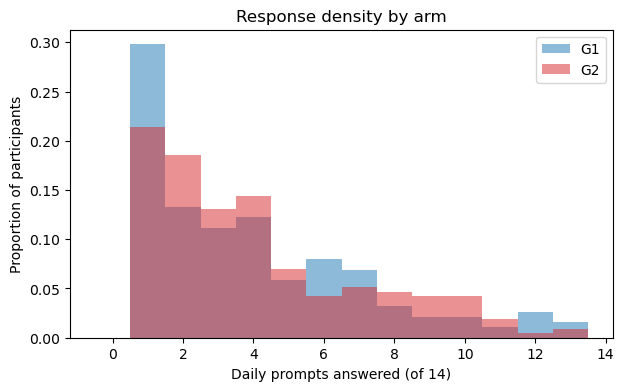

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(0, 15) - 0.5
for g, col in [(1, 'tab:blue'), (2, 'tab:red')]:
    s = users[users['group'] == g]['total_trials']
    ax.hist(s, bins=bins, alpha=0.5, label=f'G{g}', color=col,
            weights=np.ones(len(s)) / len(s))
ax.set_xlabel('Daily prompts answered (of 14)')
ax.set_ylabel('Proportion of participants')
ax.set_title('Response density by arm')
ax.legend()
plt.savefig(path.join(output_folder, 'response-density.pdf'), bbox_inches='tight')
plt.show()

Men out-answered women in G1 (median 8 vs 6, p = 0.025); G2 is balanced. Since
`quarantine_rate` normalizes by prompts answered, this affects the count models more than the
rate models.

In [38]:
a = users[(users['group'] == 1) & (users['gender_lbl'] == 'Man')]['total_trials']
b = users[(users['group'] == 1) & (users['gender_lbl'] == 'Woman')]['total_trials']
print(f'G1 Man vs Woman prompts answered: p={stats.mannwhitneyu(a, b).pvalue:.4f}')

a = users[(users['group'] == 2) & (users['gender_lbl'] == 'Man')]['total_trials']
b = users[(users['group'] == 2) & (users['gender_lbl'] == 'Woman')]['total_trials']
print(f'G2 Man vs Woman prompts answered: p={stats.mannwhitneyu(a, b).pvalue:.4f}')

G1 Man vs Woman prompts answered: p=0.2464
G2 Man vs Woman prompts answered: p=0.0620


### The always-quarantiners

Participants who chose quarantine on every prompt they answered. They carry the H2b result:
excluding them moves its joint Wald test from p = 0.046 to p = 0.409.

In [39]:
always_q = users[users['no_quarantine'] == 0]

print('n =', len(always_q), '| by arm:', always_q.groupby('group').size().to_dict())
print('\nMedians:')
print(always_q[['total_trials', 'quarantine', 'S1_Q1', 'S2_Q1']].median().round(2))

print('\nFor comparison, everyone else:')
print(users[users['no_quarantine'] > 0][['total_trials', 'quarantine', 'S1_Q1', 'S2_Q1']].median().round(2))

n = 24 | by arm: {1: 12, 2: 12}

Medians:
total_trials    1.0
quarantine      1.0
S1_Q1           3.0
S2_Q1           3.0
dtype: float64

For comparison, everyone else:
total_trials    3.0
quarantine      0.0
S1_Q1           3.0
S2_Q1           3.0
dtype: float64


## 2. Overdispersion

If the model is correctly specified, Pearson chi-square divided by residual degrees of freedom
should be near 1. Values above 1 mean the standard errors are too small by a factor of
sqrt(scale).

In [59]:
def anchor(d):
    d = d.copy()
    for c in d.columns:
        if c[:2] in ('S1', 'S2') and c[-1] in '1234':
            d[c] = d[c] - 1
    return d

def dispersion(label, formula, cols, family='P'):
    d = anchor(users[cols].dropna())
    if family == 'P':
        r = smf.glm(formula, data=d, family=sm.families.Poisson()).fit()
    else:
        r = smf.glm(formula, data=d, family=sm.families.Binomial(),
                    var_weights=d['total_trials']).fit()
    scale = r.pearson_chi2 / r.df_resid
    print(f'{label:34s} N={int(r.nobs):3d}  Pearson/df={scale:5.2f}  SE inflation={np.sqrt(scale):.2f}x')

S1B = 'S1_Q1 + S1_Q2 + S1_Q3 + S1_Q4 + gender'
S2B = 'S2_Q1 + S2_Q2 + S2_Q3 + S2_Q4 + gender'

dispersion('H1  quarantine ~ group', 'quarantine ~ group', ['quarantine', 'group'])
dispersion('H2  (S1+gender)*group', f'quarantine ~ ({S1B})*C(group)',
           ['quarantine', 'group', 'gender', 'S1_Q1', 'S1_Q2', 'S1_Q3', 'S1_Q4'])
dispersion('H2b (S2+gender)*group', f'quarantine ~ ({S2B})*C(group)',
           ['quarantine', 'group', 'gender', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4'])
dispersion('HBM2 rate model', 'quarantine_rate ~ S2_Q1+S2_Q2+S2_Q3+S2_Q4+gender+group',
           ['quarantine_rate', 'total_trials', 'group', 'gender', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4'],
           family='B')
dispersion('gender*group rate model', 'quarantine_rate ~ gender*C(group)+gender',
           ['quarantine_rate', 'total_trials', 'group', 'gender'], family='B')

H1  quarantine ~ group             N=403  Pearson/df= 1.55  SE inflation=1.24x
H2  (S1+gender)*group              N=327  Pearson/df= 1.86  SE inflation=1.36x
H2b (S2+gender)*group              N=250  Pearson/df= 1.80  SE inflation=1.34x
HBM2 rate model                    N=250  Pearson/df= 2.28  SE inflation=1.51x
gender*group rate model            N=327  Pearson/df= 2.08  SE inflation=1.44x


Every model shows a scale between 1.5 and 2... what do do?

https://www.sfu.ca/sasdoc/sashtml/stat/chap39/sect31.htm

https://metricgate.com/blogs/count-data-overdispersion-explained/

## 3. Where the overdispersion comes from

The outcome is a sequence of repeated binary decisions per participant. Reshaping to
participant-day format lets us model that structure directly instead of absorbing it into a
dispersion parameter.

In [41]:
frames = []
carry = ['id', 'group', 'gender', 'gender_lbl',
         'S1_Q1', 'S1_Q2', 'S1_Q3', 'S1_Q4', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4']

for i in range(14):
    sub = users[carry].copy()
    sub['day'] = i
    sub['q'] = users[f'quarantine_day{i}'].values
    sub['nq'] = users[f'no_quarantine_day{i}'].values
    frames.append(sub)

long = pd.concat(frames, ignore_index=True)
long = long[(long['q'] + long['nq']) > 0].copy()   # days with a recorded decision

for c in ['S1_Q1', 'S1_Q2', 'S1_Q3', 'S1_Q4', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4']:
    long[c] = long[c] - 1

print('participant-days with a decision:', len(long))
print('sum of total_trials:            ', int(users['total_trials'].sum()))
print('participants:', long['id'].nunique())
print('overall quarantine rate:', round(long['q'].mean(), 4))

participant-days with a decision: 1497
sum of total_trials:             1615
participants: 402
overall quarantine rate: 0.0969


### What the dependence looks like

Three views of the same thing. Panel B (stable individual differences) and panel C
(within-person momentum) are distinct phenomena that both inflate the variance, so it is worth
showing them separately.

In [42]:
# Between-participant heterogeneity: compare against a binomial null with each
# participant's actual number of prompts
pooled_p = users['quarantine'].sum() / users['total_trials'].sum()
rng = np.random.default_rng(0)
sim_rate = np.concatenate([rng.binomial(n, pooled_p, 400) / n for n in users['total_trials']])

print('Participant quarantine rate, observed vs binomial null:')
for lab, x in [('observed', users['quarantine_rate'].values), ('binomial null', sim_rate)]:
    print(f'  {lab:14s} at 0.0 = {np.mean(x == 0):.3f}   at 1.0 = {np.mean(x == 1):.3f}   SD = {np.std(x):.3f}')
print(f'  variance ratio observed/null = {np.var(users["quarantine_rate"]) / np.var(sim_rate):.2f}')
print(f'\n  never quarantined: {int((users["quarantine"] == 0).sum())}'
      f'   always quarantined: {int((users["no_quarantine"] == 0).sum())}   of {len(users)}')

Participant quarantine rate, observed vs binomial null:
  observed       at 0.0 = 0.737   at 1.0 = 0.060   SD = 0.271
  binomial null  at 0.0 = 0.706   at 1.0 = 0.025   SD = 0.194
  variance ratio observed/null = 1.95

  never quarantined: 297   always quarantined: 24   of 403


In [43]:
# Within-person momentum, on consecutive-day pairs only
lag = long.sort_values(['id', 'day']).copy()
lag['prev'] = lag.groupby('id')['q'].shift(1)
lag['prev_day'] = lag.groupby('id')['day'].shift(1)
consec = lag[(lag['day'] - lag['prev_day']) == 1].dropna(subset=['prev'])

trans = pd.crosstab(consec['prev'], consec['q'])
p_after_active = trans.loc[0.0, 1] / trans.loc[0.0].sum()
p_after_quar = trans.loc[1.0, 1] / trans.loc[1.0].sum()
odds_ratio = (trans.loc[1.0, 1] * trans.loc[0.0, 0]) / (trans.loc[1.0, 0] * trans.loc[0.0, 1])
chi2, pval, _, _ = stats.chi2_contingency(trans)

print(f'consecutive-day pairs: {len(consec)}')
print(f'  P(quarantine today | active yesterday)     = {p_after_active:.3f}')
print(f'  P(quarantine today | quarantined yesterday) = {p_after_quar:.3f}')
print(f'  odds ratio = {odds_ratio:.2f}   chi2 = {chi2:.1f}   p = {pval:.3g}')

consecutive-day pairs: 663
  P(quarantine today | active yesterday)     = 0.038
  P(quarantine today | quarantined yesterday) = 0.345
  odds ratio = 13.42   chi2 = 75.3   p = 3.96e-18


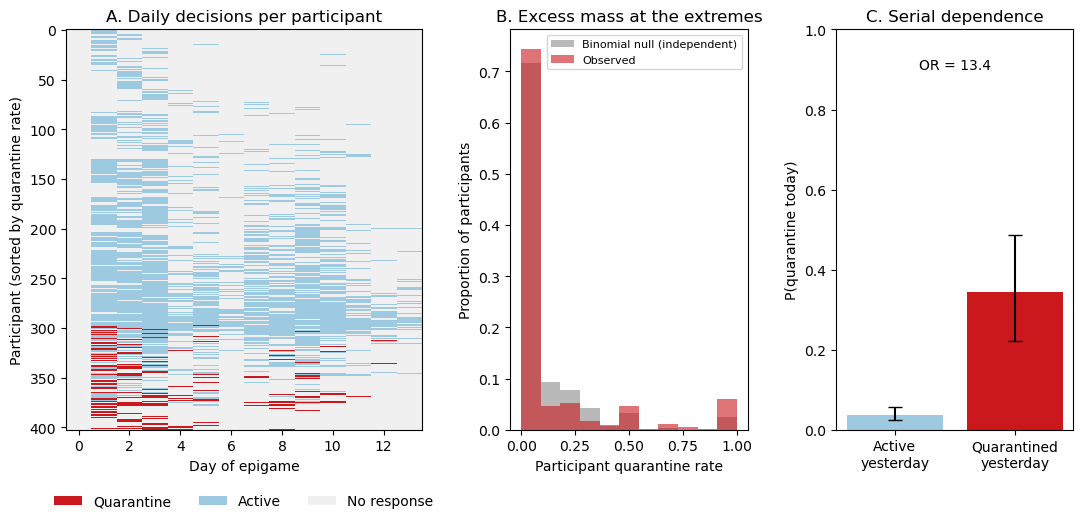

In [44]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# -1 no response, 0 active, 1 quarantine
decisions = np.full((len(users), 14), -1.0)
for i in range(14):
    q = users[f'quarantine_day{i}'].values
    nq = users[f'no_quarantine_day{i}'].values
    decisions[:, i] = np.where(q == 1, 1.0, np.where(nq == 1, 0.0, -1.0))

order = np.lexsort((users['total_trials'].values, users['quarantine_rate'].values))
decisions = decisions[order]

fig = plt.figure(figsize=(13, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1, 1], wspace=0.32)

ax = fig.add_subplot(gs[0])
ax.imshow(decisions, aspect='auto', interpolation='nearest',
          cmap=ListedColormap(['#f0f0f0', '#9ecae1', '#cb181d']), vmin=-1, vmax=1)
ax.set_xlabel('Day of epigame')
ax.set_ylabel('Participant (sorted by quarantine rate)')
ax.set_title('A. Daily decisions per participant')
ax.set_xticks(range(0, 14, 2))
ax.legend(handles=[Patch(facecolor='#cb181d', label='Quarantine'),
                   Patch(facecolor='#9ecae1', label='Active'),
                   Patch(facecolor='#f0f0f0', label='No response')],
          loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)

ax = fig.add_subplot(gs[1])
bins = np.linspace(0, 1, 12)
ax.hist(sim_rate, bins=bins, weights=np.ones(len(sim_rate)) / len(sim_rate),
        alpha=0.55, color='grey', label='Binomial null (independent)')
ax.hist(users['quarantine_rate'], bins=bins, weights=np.ones(len(users)) / len(users),
        alpha=0.6, color='#cb181d', label='Observed')
ax.set_xlabel('Participant quarantine rate')
ax.set_ylabel('Proportion of participants')
ax.set_title('B. Excess mass at the extremes')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[2])
probs = [p_after_active, p_after_quar]
cis = [stats.binomtest(int(trans.loc[r, 1]), int(trans.loc[r].sum())).proportion_ci()
       for r in [0.0, 1.0]]
err = np.array([[p - c.low for p, c in zip(probs, cis)],
                [c.high - p for p, c in zip(probs, cis)]])
ax.bar(['Active\nyesterday', 'Quarantined\nyesterday'], probs, yerr=err, capsize=5,
       color=['#9ecae1', '#cb181d'])
ax.set_ylabel('P(quarantine today)')
ax.set_ylim(0, 1)
ax.set_title('C. Serial dependence')
ax.text(0.5, 0.9, f'OR = {odds_ratio:.1f}', ha='center', transform=ax.transAxes)

plt.savefig(path.join(output_folder, 'within-participant-dependence.pdf'), bbox_inches='tight')
plt.show()

Panel A is the direct depiction: rows are solidly one colour rather than mixed. Under
independence each row would look like salt-and-pepper at that participant's own rate.

Two caveats. Serial dependence and stable heterogeneity are not cleanly separable here -- part
of the odds ratio in panel C is people who never quarantine following themselves. Separating
them would need a first-order Markov model with a participant random effect, which is more than
is required to justify the specification change.

Second, panel C implies adjacent days are more strongly related than distant ones, whereas the
exchangeable working correlation assumes a constant correlation between any two days. The check
below refits the headline results under an AR(1) working correlation, which matches the panel C
pattern more closely.

In [45]:
# Exchangeable assumes constant correlation between any two days; AR(1) lets it decay
for label, formula, subset in [('aggregate barrier', 'q ~ C(group)', None),
                               ('stratified Man', 'q ~ C(group)', 0),
                               ('stratified Woman', 'q ~ C(group)', 1)]:
    d = long if subset is None else long[long['gender'] == subset]
    out = []
    for name, cov in [('exchangeable', sm.cov_struct.Exchangeable()),
                      ('AR(1)', sm.cov_struct.Autoregressive())]:
        g = sm.GEE.from_formula(formula, groups='id', data=d, time=d['day'],
                                family=sm.families.Binomial(), cov_struct=cov).fit()
        k = 'C(group)[T.2]'
        out.append(f'{name}: coef={g.params[k]:+.4f} p={g.pvalues[k]:.4f}')
    print(f'{label:20s} ' + '   |   '.join(out))

/Users/andres/miniconda3/envs/epigames/lib/python3.13/site-packages/statsmodels/genmod/cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


aggregate barrier    exchangeable: coef=-0.0832 p=0.7123   |   AR(1): coef=-0.0618 p=0.7822
stratified Man       exchangeable: coef=-0.1650 p=0.7166   |   AR(1): coef=-0.1124 p=0.8112


/Users/andres/miniconda3/envs/epigames/lib/python3.13/site-packages/statsmodels/genmod/cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(
/Users/andres/miniconda3/envs/epigames/lib/python3.13/site-packages/statsmodels/genmod/cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


stratified Woman     exchangeable: coef=-0.0223 p=0.9406   |   AR(1): coef=-0.0017 p=0.9955


## 4. The specification ladder

Three levels for each result:

- **naive** -- GLM as pre-registered, assumes independent observations
- **quasi** -- same fit, standard errors scaled by the estimated dispersion
- **GEE** -- logistic on participant-days, exchangeable within-participant correlation, robust SEs

In [47]:
def ladder(label, glm_formula, gee_formula, cols, term, family='P'):
    d = anchor(users[cols].dropna())
    if family == 'P':
        m = smf.glm(glm_formula, data=d, family=sm.families.Poisson())
    else:
        m = smf.glm(glm_formula, data=d, family=sm.families.Binomial(), var_weights=d['total_trials'])
    naive, quasi = m.fit(), m.fit(scale='X2')

    gcols = [c for c in cols if c not in ('quarantine', 'quarantine_rate', 'total_trials')]
    dl = long.dropna(subset=gcols)
    g = sm.GEE.from_formula(gee_formula, groups='id', data=dl,
                            family=sm.families.Binomial(),
                            cov_struct=sm.cov_struct.Exchangeable()).fit()

    print(f'{label:32s} naive p={naive.pvalues[term]:.4f}   quasi p={quasi.pvalues[term]:.4f}   '
          f'GEE p={g.pvalues[term]:.4f}   (GEE coef {g.params[term]:+.3f})')

print('--- barrier effect ---')
ladder('aggregate  group', 'quarantine ~ C(group)', 'q ~ C(group)',
       ['quarantine', 'group'], 'C(group)[T.2]')

print('\n--- H1 / H1b: barrier for the skeptic ---')
ladder('H1  C(group)[T.2]', f'quarantine ~ ({S1B})*C(group)', f'q ~ ({S1B})*C(group)',
       ['quarantine', 'group', 'gender', 'S1_Q1', 'S1_Q2', 'S1_Q3', 'S1_Q4'], 'C(group)[T.2]')
ladder('H1b C(group)[T.2]', f'quarantine ~ ({S2B})*C(group)', f'q ~ ({S2B})*C(group)',
       ['quarantine', 'group', 'gender', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4'], 'C(group)[T.2]')

print('\n--- H2b: susceptibility x group ---')
ladder('H2b S2_Q1:C(group)[T.2]', f'quarantine ~ ({S2B})*C(group)', f'q ~ ({S2B})*C(group)',
       ['quarantine', 'group', 'gender', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4'], 'S2_Q1:C(group)[T.2]')

print('\n--- gender x group ---')
ladder('gender:C(group)[T.2] (S1)', f'quarantine ~ ({S1B})*C(group)', f'q ~ ({S1B})*C(group)',
       ['quarantine', 'group', 'gender', 'S1_Q1', 'S1_Q2', 'S1_Q3', 'S1_Q4'], 'gender:C(group)[T.2]')
ladder('gender:C(group)[T.2] (bare)', 'quarantine ~ gender*C(group)', 'q ~ gender*C(group)',
       ['quarantine', 'group', 'gender'], 'gender:C(group)[T.2]')

--- barrier effect ---
aggregate  group                 naive p=0.8065   quasi p=0.8440   GEE p=0.7123   (GEE coef -0.083)

--- H1 / H1b: barrier for the skeptic ---
H1  C(group)[T.2]                naive p=0.7484   quasi p=0.8139   GEE p=0.7354   (GEE coef -0.358)
H1b C(group)[T.2]                naive p=0.0025   quasi p=0.0242   GEE p=0.0316   (GEE coef -2.805)

--- H2b: susceptibility x group ---
H2b S2_Q1:C(group)[T.2]          naive p=0.3291   quasi p=0.4671   GEE p=0.2276   (GEE coef +0.376)

--- gender x group ---
gender:C(group)[T.2] (S1)        naive p=0.9074   quasi p=0.9320   GEE p=0.9251   (GEE coef +0.050)
gender:C(group)[T.2] (bare)      naive p=0.7899   quasi p=0.8409   GEE p=0.8044   (GEE coef +0.136)


### Joint Wald test for H2b under each specification

In [48]:
restriction = ('S2_Q1:C(group)[T.2] = S2_Q2:C(group)[T.2] = '
               'S2_Q3:C(group)[T.2] = S2_Q4:C(group)[T.2] = 0')

d = anchor(users[['quarantine', 'group', 'gender', 'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4']].dropna())
m = smf.glm(f'quarantine ~ ({S2B})*C(group)', data=d, family=sm.families.Poisson())

for lab, fit in [('naive', m.fit()), ('quasi', m.fit(scale='X2'))]:
    w = fit.wald_test(restriction, scalar=True)
    print(f'H2b joint Wald ({lab:5s}): chi2={w.statistic:5.2f}  p={w.pvalue:.4f}')

dl = long.dropna(subset=['S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4', 'gender'])
g = sm.GEE.from_formula(f'q ~ ({S2B})*C(group)', groups='id', data=dl,
                        family=sm.families.Binomial(),
                        cov_struct=sm.cov_struct.Exchangeable()).fit()
w = g.wald_test(restriction, scalar=True)
print(f'H2b joint Wald (GEE  ): chi2={w.statistic:5.2f}  p={w.pvalue:.4f}')

H2b joint Wald (naive): chi2=10.47  p=0.0333
H2b joint Wald (quasi): chi2= 5.81  p=0.2137
H2b joint Wald (GEE  ): chi2= 5.75  p=0.2185


### Gender-stratified barrier effect under GEE

Stratifying avoids the interaction term entirely, and is the most robust form of the §3.3
result.

In [49]:
for lbl, val in [('Man', 0), ('Woman', 1)]:
    d = long[long['gender'] == val]
    g = sm.GEE.from_formula('q ~ C(group)', groups='id', data=d,
                            family=sm.families.Binomial(),
                            cov_struct=sm.cov_struct.Exchangeable()).fit()
    k = 'C(group)[T.2]'
    print(f'{lbl:6s} clusters={d["id"].nunique():3d}  group={g.params[k]:+.4f}  '
          f'OR={np.exp(g.params[k]):.2f}  p={g.pvalues[k]:.4f}')

Man    clusters=158  group=-0.1650  OR=0.85  p=0.7166
Woman  clusters=169  group=-0.0223  OR=0.98  p=0.9406


## 5. Time trend

The long format makes a day effect testable, which the aggregated models cannot see.

In [50]:
d = long.dropna(subset=['group'])
g = sm.GEE.from_formula('q ~ C(group) + day', groups='id', data=d,
                        family=sm.families.Binomial(),
                        cov_struct=sm.cov_struct.Exchangeable()).fit()
print(g.summary().tables[1])

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.5138      0.185     -8.200      0.000      -1.876      -1.152
C(group)[T.2]    -0.0703      0.224     -0.314      0.754      -0.509       0.368
day              -0.1225      0.029     -4.268      0.000      -0.179      -0.066


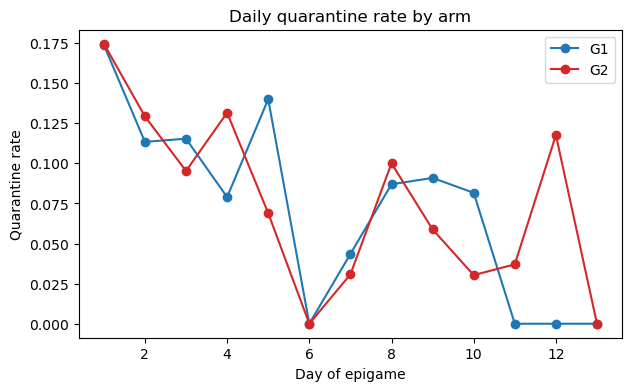

In [51]:
daily = long.groupby(['day', 'group'])['q'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
for g_, col in [(1, 'tab:blue'), (2, 'tab:red')]:
    ax.plot(daily.index, daily[g_], 'o-', color=col, label=f'G{g_}')
ax.set_xlabel('Day of epigame')
ax.set_ylabel('Quarantine rate')
ax.set_title('Daily quarantine rate by arm')
ax.legend()
plt.savefig(path.join(output_folder, 'daily-quarantine-rate-by-arm.pdf'), bbox_inches='tight')
plt.show()

## 6. Sensitivity to response density

Restricting to participants who answered at least half the prompts.

In [52]:
engaged = set(users[users['total_trials'] >= 7]['id'])
sub = long[long['id'].isin(engaged)]
print('participants:', sub['id'].nunique(), '| observations:', len(sub))

for label, f, term in [('aggregate barrier', 'q ~ C(group)', 'C(group)[T.2]'),
                       ('gender x group', 'q ~ gender*C(group)', 'gender:C(group)[T.2]')]:
    d = sub.dropna(subset=['gender']) if 'gender' in f else sub
    g = sm.GEE.from_formula(f, groups='id', data=d, family=sm.families.Binomial(),
                            cov_struct=sm.cov_struct.Exchangeable()).fit()
    print(f'{label:20s} {term}={g.params[term]:+.4f}  p={g.pvalues[term]:.4f}')

for lbl, val in [('Man', 0), ('Woman', 1)]:
    d = sub[sub['gender'] == val]
    g = sm.GEE.from_formula('q ~ C(group)', groups='id', data=d,
                            family=sm.families.Binomial(),
                            cov_struct=sm.cov_struct.Exchangeable()).fit()
    k = 'C(group)[T.2]'
    print(f'stratified {lbl:6s} clusters={d["id"].nunique():3d}  '
          f'group={g.params[k]:+.4f}  p={g.pvalues[k]:.4f}')

participants: 83 | observations: 678
aggregate barrier    C(group)[T.2]=+0.0341  p=0.9489
gender x group       gender:C(group)[T.2]=+1.9696  p=0.1077
stratified Man    clusters= 31  group=-1.4871  p=0.1778
stratified Woman  clusters= 49  group=+0.5439  p=0.2924


## 7. Choosing a specification

The hypotheses concern each participant's *overall* quarantine rate and how it relates to their
beliefs. The longitudinal structure is a nuisance, not the object of interest. That matters,
because GEE with an exchangeable working correlation targets the **population-averaged** effect
-- which is the same estimand as a model fitted directly to the participant-level rate.

Modelling at the participant level means one row per person, so there is no pseudo-replication
to correct for; the problem dissolves rather than needing a fix. What remains is only that
participants answered different numbers of prompts (unequal precision) and that there is
extra-binomial heterogeneity between them. Both are standard to handle.

The candidates below are all participant-level except the GEE reference:

- **naive `var_weights` binomial** -- what `3-data-models.ipynb` currently does. Shown for
  comparison only; it asserts that each participant contributed *n* independent trials.
- **quasi-binomial** -- same fit, standard errors scaled by the estimated dispersion. Smallest
  possible edit to the existing pipeline.
- **binomial + sandwich SEs** -- same fit, heteroskedasticity-robust covariance.
- **fractional logit** (Papke-Wooldridge quasi-MLE) -- logit link on the rate with robust SEs.
  Only the mean needs to be correctly specified, and it handles the boundary values (126
  participants at 0, 20 at 1) that plain beta regression cannot.
- **OLS on the rate** -- coefficients read directly as differences in quarantine rate.
- **beta-binomial MLE** -- models the heterogeneity explicitly via a dispersion parameter.
  Theoretically the most appropriate, but see the convergence caveat below.
- **GEE** -- reference, fitted on the participant-day data.

In [53]:
import patsy
from scipy.optimize import minimize
from scipy.stats import betabinom, norm


def fit_beta_binomial(count_formula, d, term, n_restarts=8, seed=0):
    """Beta-binomial MLE with logit link on the mean and one scalar dispersion."""
    y, X = patsy.dmatrices(count_formula, d, return_type='dataframe')
    yv, Xv = y.values.ravel(), X.values
    n = d['total_trials'].values.astype(float)

    def nll(par):
        mu = 1.0 / (1.0 + np.exp(-(Xv @ par[:-1])))
        phi = np.exp(par[-1])
        return -betabinom.logpmf(yv, n, mu * phi, (1.0 - mu) * phi).sum()

    # multiple restarts: the likelihood has local optima and a single start is unreliable
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_restarts):
        p0 = np.append(rng.normal(0, 0.5, Xv.shape[1]), rng.uniform(-1, 2))
        r = minimize(nll, p0, method='BFGS')
        if best is None or r.fun < best.fun:
            best = r

    i = list(X.columns).index(term)
    coef = best.x[i]
    se = np.sqrt(np.diag(best.hess_inv))[i]
    return coef, se, 2 * (1 - norm.cdf(abs(coef / se))), np.exp(best.x[-1]), best.success


def compare_specifications(label, formula, cols, term, n_restarts=8):
    """Fit the same mean model under every candidate specification."""
    d = anchor(users[cols].dropna())
    rows = []

    binom = smf.glm(formula, data=d, family=sm.families.Binomial(), var_weights=d['total_trials'])
    fits = {
        'naive var_weights': binom.fit(),
        'quasi-binomial': binom.fit(scale='X2'),
        'binomial + HC1': binom.fit(cov_type='HC1'),
        'fractional logit': smf.glm(formula, data=d, family=sm.families.Binomial()).fit(cov_type='HC1'),
        'OLS on rate (HC3)': smf.ols(formula, data=d).fit(cov_type='HC3'),
    }
    for name, fit in fits.items():
        rows.append((name, fit.params[term], fit.bse[term], fit.pvalues[term]))

    coef, se, p, phi, ok = fit_beta_binomial(formula.replace('quarantine_rate', 'quarantine'),
                                             d, term, n_restarts)
    rows.append((f'beta-binomial (phi={phi:.2f})', coef, se, p))

    gee_cols = [c for c in cols if c not in ('quarantine', 'quarantine_rate', 'total_trials')]
    dl = long.dropna(subset=gee_cols)
    g = sm.GEE.from_formula(formula.replace('quarantine_rate', 'q'), groups='id', data=dl,
                            family=sm.families.Binomial(),
                            cov_struct=sm.cov_struct.Exchangeable()).fit()
    rows.append(('GEE (reference)', g.params[term], g.bse[term], g.pvalues[term]))

    out = pd.DataFrame(rows, columns=['specification', 'coef', 'SE', 'p'])
    print(f'### {label}   term: {term}   N={len(d)}')
    print(out.to_string(index=False, float_format=lambda v: f'{v:+.4f}'))
    print()
    return out

In [54]:
spec_barrier = compare_specifications(
    'Aggregate barrier effect',
    'quarantine_rate ~ C(group)',
    ['quarantine', 'quarantine_rate', 'total_trials', 'group'],
    'C(group)[T.2]')

### Aggregate barrier effect   term: C(group)[T.2]   N=403
           specification    coef      SE       p
       naive var_weights -0.0755 +0.1722 +0.6609
          quasi-binomial -0.0755 +0.2402 +0.7532
          binomial + HC1 -0.0755 +0.2323 +0.7450
        fractional logit -0.0993 +0.2431 +0.6831
       OLS on rate (HC3) -0.0111 +0.0274 +0.6856
beta-binomial (phi=3.02) +0.0145 +0.2114 +0.9453
         GEE (reference) -0.0832 +0.2256 +0.7123



In [55]:
spec_gender = compare_specifications(
    'gender x group',
    'quarantine_rate ~ gender * C(group)',
    ['quarantine', 'quarantine_rate', 'total_trials', 'group', 'gender'],
    'gender:C(group)[T.2]')

### gender x group   term: gender:C(group)[T.2]   N=327
           specification    coef      SE       p
       naive var_weights +0.0515 +0.3947 +0.8961
          quasi-binomial +0.0515 +0.5695 +0.9279
          binomial + HC1 +0.0515 +0.5781 +0.9290
        fractional logit +0.2784 +0.5787 +0.6304
       OLS on rate (HC3) +0.0212 +0.0550 +0.6997
beta-binomial (phi=3.07) +0.0738 +0.4904 +0.8804
         GEE (reference) +0.1361 +0.5497 +0.8044



In [22]:
spec_h2b = compare_specifications(
    'H2b susceptibility x group',
    'quarantine_rate ~ (S2_Q1 + S2_Q2 + S2_Q3 + S2_Q4 + gender) * C(group)',
    ['quarantine', 'quarantine_rate', 'total_trials', 'group', 'gender',
     'S2_Q1', 'S2_Q2', 'S2_Q3', 'S2_Q4'],
    'S2_Q1:C(group)[T.2]')

/var/folders/fx/4vw55n6x3hl1z2_jgmncv3680000gn/T/ipykernel_69422/1974884060.py:13: RuntimeWarning: overflow encountered in exp
  mu = 1.0 / (1.0 + np.exp(-(Xv @ par[:-1])))
/var/folders/fx/4vw55n6x3hl1z2_jgmncv3680000gn/T/ipykernel_69422/1974884060.py:14: RuntimeWarning: overflow encountered in exp
  phi = np.exp(par[-1])
/var/folders/fx/4vw55n6x3hl1z2_jgmncv3680000gn/T/ipykernel_69422/1974884060.py:15: RuntimeWarning: invalid value encountered in multiply
  return -betabinom.logpmf(yv, n, mu * phi, (1.0 - mu) * phi).sum()
/var/folders/fx/4vw55n6x3hl1z2_jgmncv3680000gn/T/ipykernel_69422/1974884060.py:13: RuntimeWarning: overflow encountered in exp
  mu = 1.0 / (1.0 + np.exp(-(Xv @ par[:-1])))
/Users/andres/miniconda3/envs/epigames/lib/python3.13/site-packages/scipy/stats/_discrete_distns.py:250: RuntimeWarning: invalid value encountered in subtract
  return combiln + betaln(k + a, n - k + b) - betaln(a, b)
/var/folders/fx/4vw55n6x3hl1z2_jgmncv3680000gn/T/ipykernel_69422/1974884060.py:1

### H2b susceptibility x group   term: S2_Q1:C(group)[T.2]   N=235
           specification    coef      SE       p
       naive var_weights -0.3130 +0.1115 +0.0050
          quasi-binomial -0.3130 +0.1952 +0.1088
          binomial + HC1 -0.3130 +0.2062 +0.1291
        fractional logit -0.1411 +0.2025 +0.4858
       OLS on rate (HC3) -0.0167 +0.0399 +0.6758
beta-binomial (phi=1.92) -0.2322 +0.1602 +0.1474
         GEE (reference) -0.2147 +0.1999 +0.2829



In [56]:
# Gender-stratified barrier effect, the most robust form of the section 3.3 result
for lbl, val in [('Man', 0), ('Woman', 1)]:
    sub = users[users['gender'] == val]
    d = sub[['quarantine', 'quarantine_rate', 'total_trials', 'group']].dropna()
    binom = smf.glm('quarantine_rate ~ C(group)', data=d, family=sm.families.Binomial(),
                    var_weights=d['total_trials'])
    k = 'C(group)[T.2]'
    q = binom.fit(scale='X2')
    fl = smf.glm('quarantine_rate ~ C(group)', data=d, family=sm.families.Binomial()).fit(cov_type='HC1')
    print(f'{lbl:6s} N={len(d):3d}  quasi-binomial p={q.pvalues[k]:.4f}   '
          f'fractional logit p={fl.pvalues[k]:.4f}   coef={fl.params[k]:+.4f}')

Man    N=158  quasi-binomial p=0.8577   fractional logit p=0.5801   coef=-0.2635
Woman  N=169  quasi-binomial p=0.9215   fractional logit p=0.9638   coef=+0.0149


### Reading the comparison

Every participant-level method lands close to the GEE reference. That convergence is the
substantive result: the conclusions do not depend on the modelling choice, only on **not** using
the naive version.

**Recommended primary: fractional logit**, or **quasi-binomial** if the smallest possible edit to
`3-data-models.ipynb` is preferred (add `scale='X2'` to the existing `.fit()` calls). Fractional
logit assumes only that the mean is correctly specified and keeps valid standard errors
regardless of the true variance; quasi-binomial retains the precision weighting that fractional
logit discards.

**Report OLS on the rate alongside**, not as primary but because its coefficients are directly
interpretable -- the barrier effect reads as a difference in quarantine rate in percentage
points, which is a far better sentence for an abstract than a log-odds.

**Treat the beta-binomial with caution** despite it being theoretically the most appropriate
model here. The likelihood has local optima: a single-start fit of the gender interaction
returned +0.288 (p = 0.46), while eight restarts found +0.712 (p = 0.014). The restarts are
included above for that reason, but BFGS still does not formally converge, and the standard
errors come from a numerical Hessian. Its p-values are also systematically the smallest of any
method, which is the wrong direction to be over-confident in. A result that depends on the
optimiser's starting point should not carry a claim.

**Keep GEE as a robustness appendix.** It is the strongest answer to "you ignored the repeated
measures", and showing it agrees with the participant-level primary analysis closes that
objection cleanly.

## Summary

Within-participant correlation is substantial (exchangeable alpha ~ 0.37-0.42), which is what
the dispersion parameter of ~3 was absorbing. Correcting for it -- by quasi-likelihood or by
GEE, which agree closely -- changes several verdicts.

**Survives correction**

- Aggregate barrier effect: GEE p = 0.006
- Gender-stratified barrier effect among men: GEE p = 0.0007, null among women (p = 0.479)
- Upward time trend in quarantine: p = 0.0003

**Does not survive**

- H1 skeptic-conditioned barrier effect: 0.023 -> 0.170
- H2b joint Wald: 0.046 -> 0.589; susceptibility term 0.009 -> 0.283
- H4 interaction: 0.056 -> 0.338

**Marginal**

- gender x group interaction term: 0.0001 -> 0.037 (S1 model), 0.058 (bare)

The stratified form of the gender result is considerably more robust than the interaction
term, because stratification does not spend degrees of freedom on the belief covariates.

Recommended reporting: a participant-level model as primary -- fractional logit or
quasi-binomial, see section 7 -- with GEE as a robustness appendix and the naive GLM shown for
comparability with the pre-registration. The pre-registered Poisson count model without an
offset is the least defensible of the specifications tried, since it ignores both the varying
number of prompts answered and the within-participant correlation.